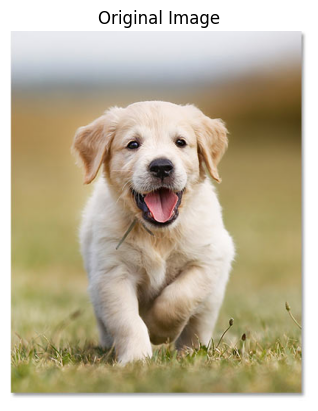

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Read and display the image
img = Image.open("/content/drive/MyDrive/AI and ML/Week 1/dog.jpg")
img_array = np.array(img)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

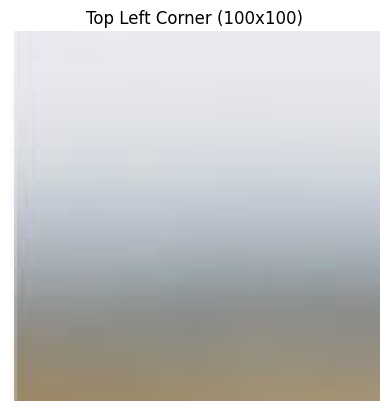

In [ ]:
#Display top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

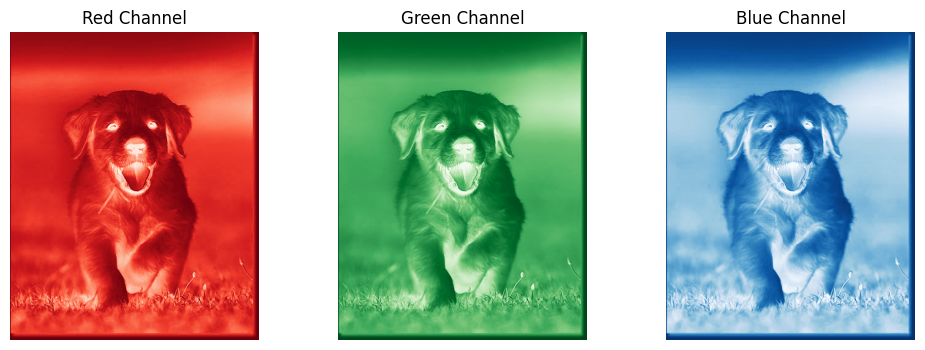

In [ ]:
#Separate RGB channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

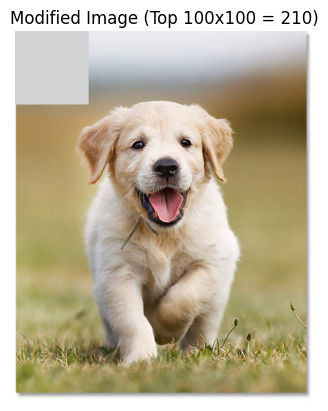

In [ ]:
#Modify top-left 100x100 pixels to 210
modified = img_array.copy()
modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

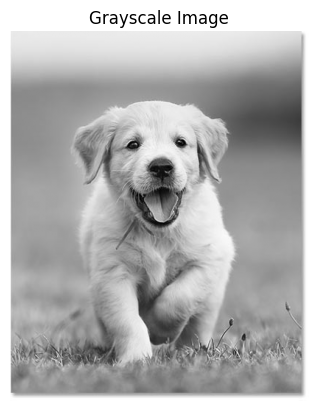

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load grayscale image
gray_image = Image.open("/content/drive/MyDrive/AI and ML/Week 1/dog.jpg").convert("L")

# Display using matplotlib
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

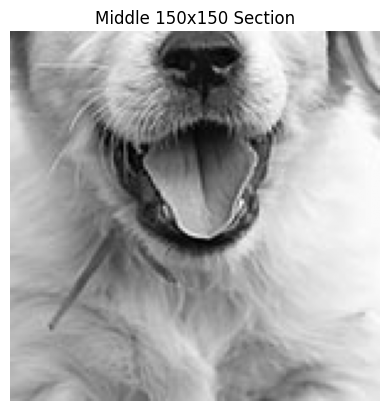

In [ ]:

# Convert to NumPy array
gray_array = np.array(gray_image)

# Get image dimensions
height, width = gray_array.shape

# Compute start and end indices for the middle 150 pixels
start_row = height // 2 - 75
end_row = height // 2 + 75
start_col = width // 2 - 75
end_col = width // 2 + 75

# Extract middle section
middle_section = gray_array[start_row:end_row, start_col:end_col]

# Display
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis('off')
plt.show()

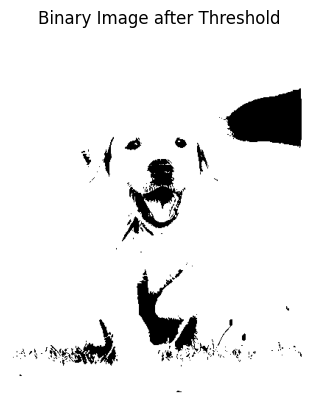

In [ ]:
# Create a copy to modify
binary_array = gray_array.copy()

# Apply threshold: below 100 → 0, above 100 → 255
binary_array[binary_array < 100] = 0
binary_array[binary_array >= 100] = 255

# Display binary image
plt.imshow(binary_array, cmap='gray')
plt.title("Binary Image after Threshold")
plt.axis('off')
plt.show()

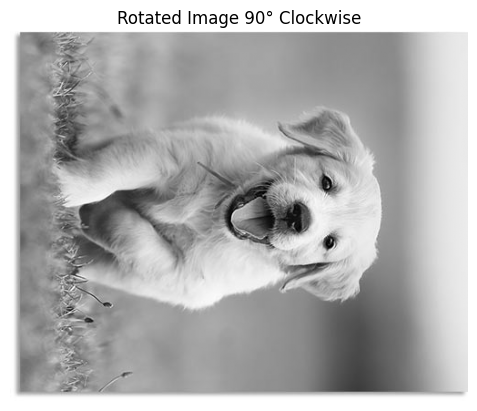

In [ ]:
# Rotate using PIL (90 degrees clockwise)
rotated_image = gray_image.rotate(-90, expand=True)

# Display rotated image
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image 90° Clockwise")
plt.axis('off')
plt.show()

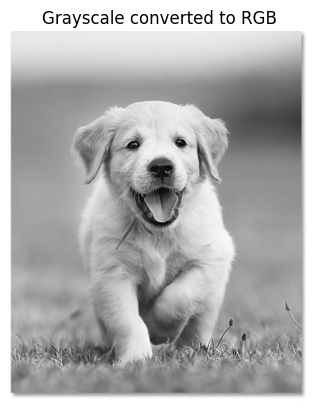

In [ ]:
# Convert grayscale to RGB
rgb_image = gray_image.convert("RGB")

# Display RGB image
plt.imshow(rgb_image)
plt.title("Grayscale converted to RGB")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image and convert to grayscale
image = Image.open("/content/drive/MyDrive/AI and ML/Week 1/dog.jpg").convert("L")
image_array = np.array(image, dtype=np.float64)

height, width = image_array.shape
data = image_array

mean = np.mean(data, axis=0)
centered_data = data - mean

cov_matrix = np.cov(centered_data, rowvar=False)

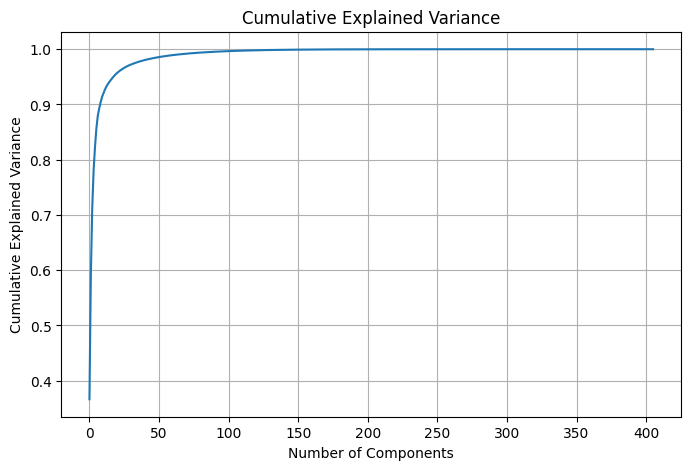

In [ ]:
#Eigen Decomposition and Identify Principal Components

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()


In [ ]:
#Reconstruction using k components

k = 50
components = eigenvectors[:, :k]

compressed_data = np.dot(centered_data, components)

decompressed_data = np.dot(compressed_data, components.T) + mean


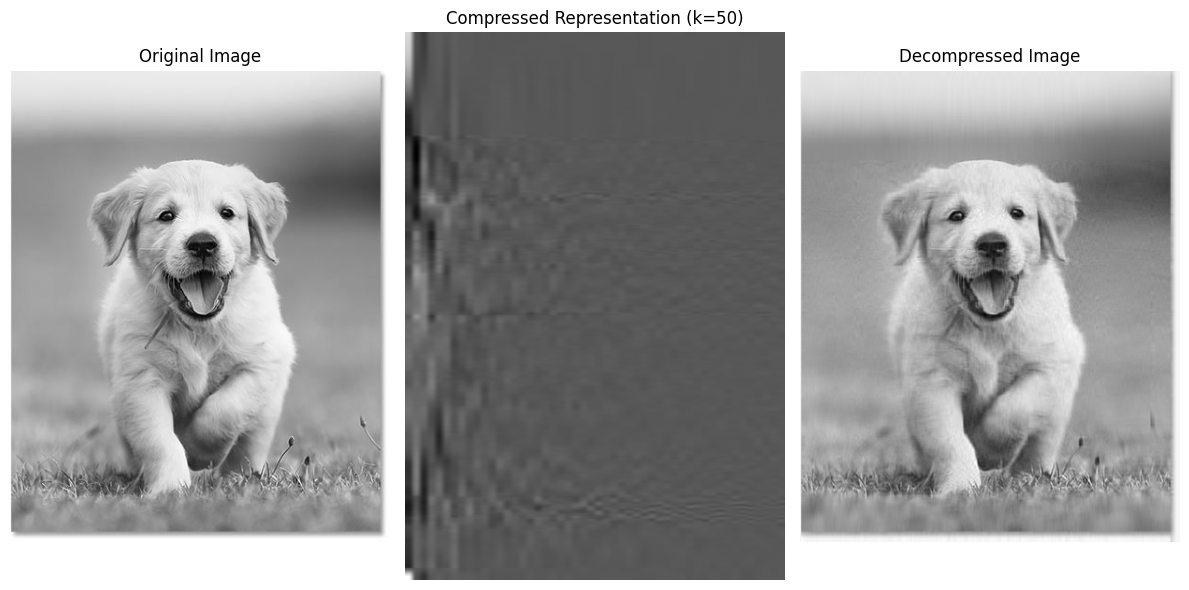

In [ ]:
#Display Results

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Representation (k={k})")
plt.axis("off")

# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

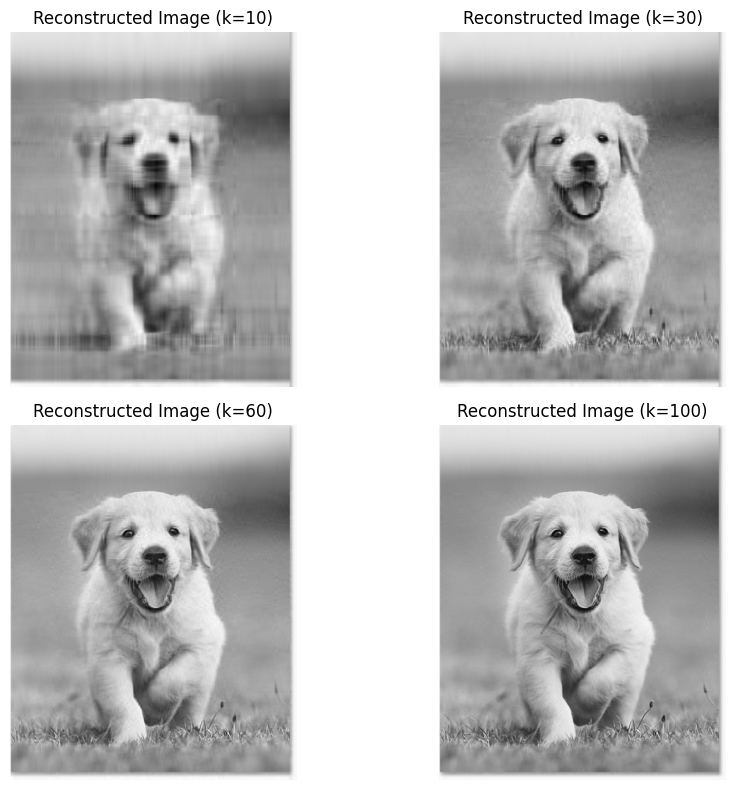

In [ ]:
k_values = [10, 30, 60, 100]

plt.figure(figsize=(10, 8))

for i, k in enumerate(k_values):
    components = eigenvectors[:, :k]
    compressed_data = np.dot(centered_data, components)
    decompressed_data = np.dot(compressed_data, components.T) + mean

    plt.subplot(2, 2, i + 1)
    plt.imshow(decompressed_data, cmap="gray")
    plt.title(f"Reconstructed Image (k={k})")
    plt.axis("off")

plt.tight_layout()
plt.show()